# Recipe Healthiness Prediction - Machine Learning Pipeline

This notebook implements a supervised machine learning pipeline to classify recipes into three categories:
- **Healthy**
- **Moderately Healthy**
- **Unhealthy**

Models implemented: SVM and Random Forest Classifier

## Step 1: Import Required Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Metrics and evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Explore Dataset

In [2]:
# Load the dataset
df = pd.read_csv('RecipeNLG_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (2231142, 7)

Column names: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']

First few rows:


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


In [3]:
# Check data info and missing values
print("Dataset Information:")
print(f"Total records: {len(df)}")
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)

# Sample a manageable subset if dataset is very large (optional)
if len(df) > 50000:
    print(f"\nSampling 50000 records for faster processing...")
    df = df.sample(n=50000, random_state=42).reset_index(drop=True)
    print(f"Working with {len(df)} records")

Dataset Information:
Total records: 2231142

Missing values:
Unnamed: 0     0
title          1
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64

Data types:
Unnamed: 0     int64
title            str
ingredients      str
directions       str
link             str
source           str
NER              str
dtype: object

Sampling 50000 records for faster processing...
Working with 50000 records


## Step 3: Text Data Cleaning

In [4]:
# Initialize text processing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Clean text data:
    - Convert to lowercase
    - Remove punctuation and special characters
    - Remove stopwords
    - Perform lemmatization
    """
    if pd.isna(text):
        return ""
    
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove special characters and punctuation, keep only alphabets and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Split into words
    words = text.split()
    
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    
    return ' '.join(words)

print("Text cleaning function defined successfully!")

Text cleaning function defined successfully!


In [5]:
# Identify the correct column names for ingredients and directions
# Common column names in RecipeNLG: 'NER' or 'ingredients' for ingredients, 'directions' for instructions

print("Applying text cleaning to dataset...")
print("This may take a few moments...\n")

# Handle different possible column names
if 'NER' in df.columns:
    ingredients_col = 'NER'
elif 'ingredients' in df.columns:
    ingredients_col = 'ingredients'
else:
    ingredients_col = df.columns[1]  # Use second column if standard names not found

if 'directions' in df.columns:
    directions_col = 'directions'
elif 'instructions' in df.columns:
    directions_col = 'instructions'
else:
    directions_col = df.columns[2]  # Use third column if standard names not found

print(f"Using '{ingredients_col}' column for ingredients")
print(f"Using '{directions_col}' column for directions")

# Clean the text data
df['cleaned_ingredients'] = df[ingredients_col].apply(clean_text)
df['cleaned_directions'] = df[directions_col].apply(clean_text)

# Combine ingredients and directions for comprehensive analysis
df['combined_text'] = df['cleaned_ingredients'] + ' ' + df['cleaned_directions']

print("\nText cleaning completed!")
print(f"\nExample of cleaned text:")
print(df['combined_text'].iloc[0][:200] + "...")

Applying text cleaning to dataset...
This may take a few moments...

Using 'NER' column for ingredients
Using 'directions' column for directions

Text cleaning completed!

Example of cleaned text:
flank steak green onion red wine soy sauce salad oil sesame seed brown sugar grnd black pepper grnd ginger clove garlic remove tenderloin steak score meat combine remaining ingredient pour meat let ma...


## Step 4: Create Healthiness Labels (Rule-Based Scoring)

In [6]:
# Define health indicators
unhealthy_indicators = [
    'sugar', 'butter', 'cream', 'fried', 'deep', 'chocolate', 
    'candy', 'syrup', 'bacon', 'sausage', 'processed', 'mayo',
    'mayonnaise', 'cheese', 'fat', 'lard', 'shortening'
]

healthy_indicators = [
    'vegetable', 'fruit', 'grain', 'whole', 'steamed', 'grilled',
    'baked', 'legume', 'nut', 'seed', 'spinach', 'broccoli',
    'carrot', 'tomato', 'lettuce', 'kale', 'quinoa', 'oat',
    'apple', 'banana', 'berry', 'orange', 'lentil', 'bean',
    'chickpea', 'almond', 'walnut', 'salmon', 'chicken breast'
]

def calculate_health_score(text):
    """
    Calculate health score based on presence of healthy/unhealthy indicators
    Returns: score (int)
    """
    if pd.isna(text):
        return 0
    
    text = str(text).lower()
    score = 0
    
    # Count healthy indicators (+1 each)
    for indicator in healthy_indicators:
        if indicator in text:
            score += 1
    
    # Count unhealthy indicators (-1 each)
    for indicator in unhealthy_indicators:
        if indicator in text:
            score -= 1
    
    return score

def assign_health_label(score):
    """
    Assign health label based on score:
    - Score >= 2 → Healthy
    - Score between -1 and 1 → Moderately Healthy
    - Score <= -2 → Unhealthy
    """
    if score >= 2:
        return 'Healthy'
    elif score <= -2:
        return 'Unhealthy'
    else:
        return 'Moderately Healthy'

print("Health scoring functions defined successfully!")

Health scoring functions defined successfully!


Calculating health scores...

Health Label Distribution:
health_label
Moderately Healthy    29907
Healthy               10570
Unhealthy              9523
Name: count, dtype: int64

Percentage Distribution:
health_label
Moderately Healthy    59.814
Healthy               21.140
Unhealthy             19.046
Name: proportion, dtype: float64


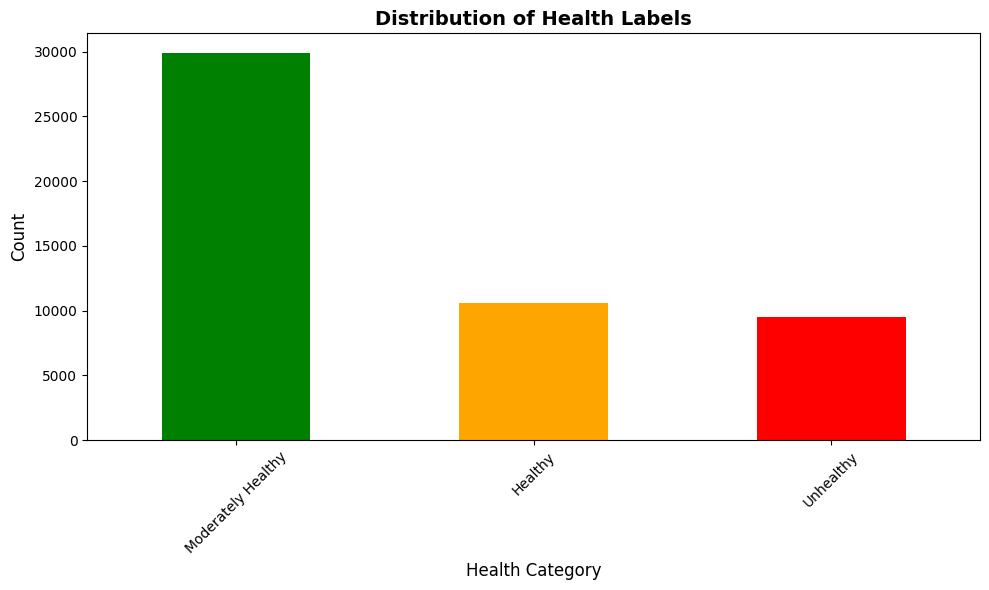


Dataset now has 50000 recipes with health labels!


In [7]:
# Calculate health scores and assign labels
print("Calculating health scores...")
df['health_score'] = df['combined_text'].apply(calculate_health_score)
df['health_label'] = df['health_score'].apply(assign_health_label)

# Display distribution of labels
print("\nHealth Label Distribution:")
print(df['health_label'].value_counts())
print("\nPercentage Distribution:")
print(df['health_label'].value_counts(normalize=True) * 100)

# Visualize label distribution
plt.figure(figsize=(10, 6))
df['health_label'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribution of Health Labels', fontsize=14, fontweight='bold')
plt.xlabel('Health Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nDataset now has {len(df)} recipes with health labels!")

## Step 5: Feature Engineering

In [8]:
# Create TF-IDF features from ingredients text
print("Creating TF-IDF features from ingredients...")

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),  # Include unigrams and bigrams
    min_df=5,  # Minimum document frequency
    max_df=0.8  # Maximum document frequency
)

# Fit and transform the cleaned ingredients text
tfidf_features = tfidf_vectorizer.fit_transform(df['cleaned_ingredients'])

print(f"TF-IDF feature matrix shape: {tfidf_features.shape}")
print(f"Number of unique terms: {len(tfidf_vectorizer.get_feature_names_out())}")

# Create additional structured features
df['num_ingredients'] = df['cleaned_ingredients'].apply(lambda x: len(str(x).split()))
df['instruction_length'] = df['cleaned_directions'].apply(lambda x: len(str(x).split()))

# Binary cooking method indicators
df['is_baked'] = df['combined_text'].apply(lambda x: 1 if 'bake' in str(x).lower() else 0)
df['is_fried'] = df['combined_text'].apply(lambda x: 1 if 'fry' in str(x).lower() or 'fried' in str(x).lower() else 0)
df['is_grilled'] = df['combined_text'].apply(lambda x: 1 if 'grill' in str(x).lower() else 0)
df['is_steamed'] = df['combined_text'].apply(lambda x: 1 if 'steam' in str(x).lower() else 0)

# Combine TF-IDF features with structured features
structured_features = df[['num_ingredients', 'instruction_length', 
                          'is_baked', 'is_fried', 'is_grilled', 'is_steamed']].values

# Convert TF-IDF sparse matrix to dense and combine with structured features
from scipy.sparse import hstack, csr_matrix

X_combined = hstack([tfidf_features, csr_matrix(structured_features)])

print(f"\nFinal feature matrix shape: {X_combined.shape}")
print(f"Number of features: {X_combined.shape[1]}")
print("\nStructured features created:")
print(f"  - Number of ingredients")
print(f"  - Instruction length")
print(f"  - Binary cooking method indicators (baked, fried, grilled, steamed)")
print("\nFeature engineering completed!")

Creating TF-IDF features from ingredients...
TF-IDF feature matrix shape: (50000, 5000)
Number of unique terms: 5000

Final feature matrix shape: (50000, 5006)
Number of features: 5006

Structured features created:
  - Number of ingredients
  - Instruction length
  - Binary cooking method indicators (baked, fried, grilled, steamed)

Feature engineering completed!


## Step 6: Train-Test Split

In [9]:
# Prepare features and target
X = X_combined
y = df['health_label']

# Split dataset into 80% train and 20% test with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Train-Test Split Completed!")
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set label distribution:")
print(y_train.value_counts())
print(f"\nTest set label distribution:")
print(y_test.value_counts())

Train-Test Split Completed!

Training set size: 40000
Test set size: 10000

Training set label distribution:
health_label
Moderately Healthy    23926
Healthy                8456
Unhealthy              7618
Name: count, dtype: int64

Test set label distribution:
health_label
Moderately Healthy    5981
Healthy               2114
Unhealthy             1905
Name: count, dtype: int64


## Step 7: Model 1 - Support Vector Machine (SVM)

In [10]:
# Train Support Vector Machine (LinearSVC)
print("Training Support Vector Machine (LinearSVC)...")
print("This may take a few minutes...\n")

svm_model = LinearSVC(random_state=42, max_iter=1000, dual=False)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

print("SVM Training completed!")
print(f"Model trained on {X_train.shape[0]} samples")
print(f"Predictions made on {X_test.shape[0]} samples")

Training Support Vector Machine (LinearSVC)...
This may take a few minutes...

SVM Training completed!
Model trained on 40000 samples
Predictions made on 10000 samples


In [11]:
# Evaluate SVM Model
print("="*60)
print("SUPPORT VECTOR MACHINE (SVM) - EVALUATION RESULTS")
print("="*60)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

print(f"\nAccuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1-Score:  {svm_f1:.4f}")

print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=['Healthy', 'Moderately Healthy', 'Unhealthy'])
print("\nConfusion Matrix:")
print(svm_cm)

SUPPORT VECTOR MACHINE (SVM) - EVALUATION RESULTS

Accuracy:  0.7470
Precision: 0.7335
Recall:    0.6819
F1-Score:  0.7033

Classification Report:
                    precision    recall  f1-score   support

           Healthy       0.72      0.62      0.67      2114
Moderately Healthy       0.76      0.84      0.80      5981
         Unhealthy       0.72      0.58      0.64      1905

          accuracy                           0.75     10000
         macro avg       0.73      0.68      0.70     10000
      weighted avg       0.74      0.75      0.74     10000


Confusion Matrix:
[[1307  803    4]
 [ 490 5053  438]
 [   6  789 1110]]


## Step 8: Model 2 - Random Forest Classifier

In [12]:
# Train Random Forest Classifier
print("Training Random Forest Classifier...")
print("This may take a few minutes...\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,  # Use all available cores
    max_depth=20,
    min_samples_split=5
)

rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Training completed!")
print(f"Model trained on {X_train.shape[0]} samples")
print(f"Predictions made on {X_test.shape[0]} samples")

Training Random Forest Classifier...
This may take a few minutes...

Random Forest Training completed!
Model trained on 40000 samples
Predictions made on 10000 samples


In [13]:
# Evaluate Random Forest Model
print("="*60)
print("RANDOM FOREST CLASSIFIER - EVALUATION RESULTS")
print("="*60)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='macro')
rf_recall = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"\nAccuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")

print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
rf_cm = confusion_matrix(y_test, y_pred_rf, labels=['Healthy', 'Moderately Healthy', 'Unhealthy'])
print("\nConfusion Matrix:")
print(rf_cm)

RANDOM FOREST CLASSIFIER - EVALUATION RESULTS

Accuracy:  0.6747
Precision: 0.7853
Recall:    0.4776
F1-Score:  0.5016

Classification Report:
                    precision    recall  f1-score   support

           Healthy       0.85      0.24      0.38      2114
Moderately Healthy       0.65      0.97      0.78      5981
         Unhealthy       0.85      0.22      0.35      1905

          accuracy                           0.67     10000
         macro avg       0.79      0.48      0.50     10000
      weighted avg       0.73      0.67      0.61     10000


Confusion Matrix:
[[ 513 1600    1]
 [  90 5821   70]
 [   1 1491  413]]


## Step 9: Model Performance Comparison

MODEL PERFORMANCE COMPARISON
                       Model  Accuracy  Precision   Recall  F1-Score
Support Vector Machine (SVM)    0.7470   0.733510 0.681926  0.703312
    Random Forest Classifier    0.6747   0.785269 0.477571  0.501648


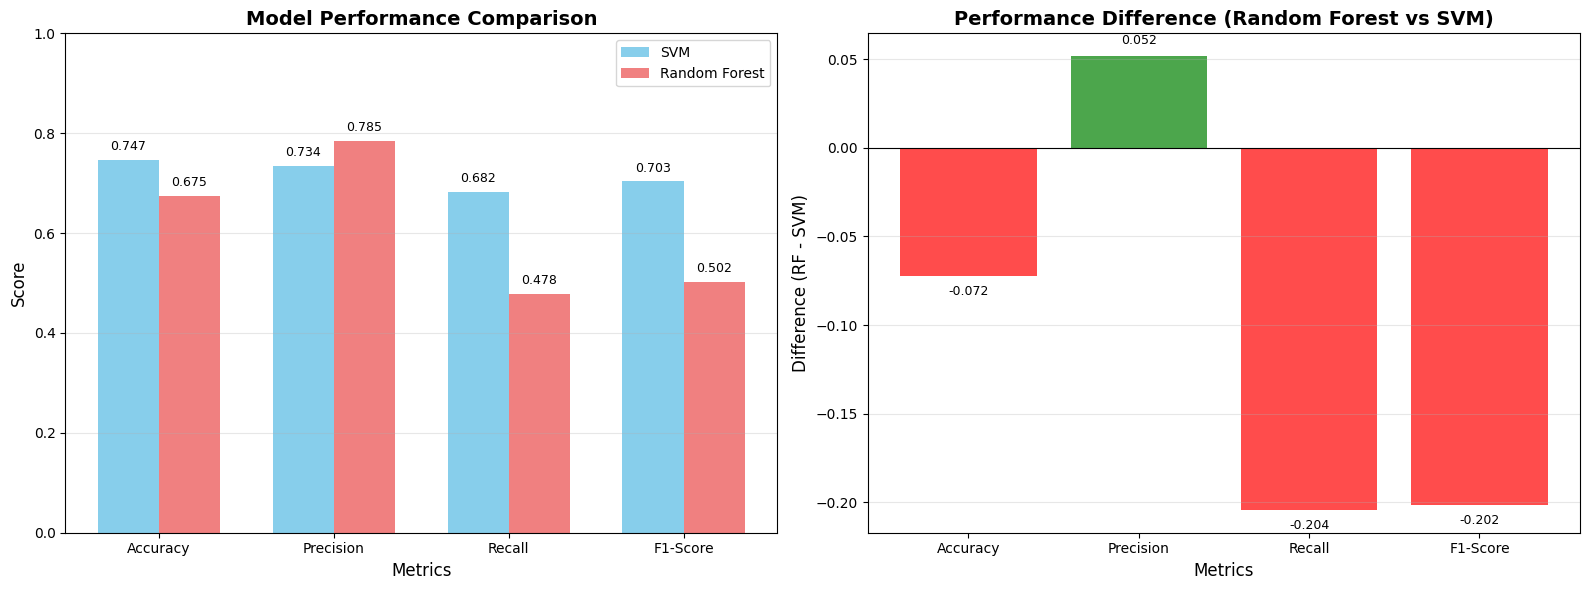

In [14]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Support Vector Machine (SVM)', 'Random Forest Classifier'],
    'Accuracy': [svm_accuracy, rf_accuracy],
    'Precision': [svm_precision, rf_precision],
    'Recall': [svm_recall, rf_recall],
    'F1-Score': [svm_f1, rf_f1]
})

print("="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [svm_accuracy, svm_precision, svm_recall, svm_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, svm_scores, width, label='SVM', color='skyblue')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='lightcoral')
axes[0].set_xlabel('Metrics', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (svm_val, rf_val) in enumerate(zip(svm_scores, rf_scores)):
    axes[0].text(i - width/2, svm_val + 0.02, f'{svm_val:.3f}', ha='center', fontsize=9)
    axes[0].text(i + width/2, rf_val + 0.02, f'{rf_val:.3f}', ha='center', fontsize=9)

# Performance difference
differences = [rf - svm for rf, svm in zip(rf_scores, svm_scores)]
colors = ['green' if d > 0 else 'red' for d in differences]
axes[1].bar(metrics, differences, color=colors, alpha=0.7)
axes[1].set_xlabel('Metrics', fontsize=12)
axes[1].set_ylabel('Difference (RF - SVM)', fontsize=12)
axes[1].set_title('Performance Difference (Random Forest vs SVM)', fontsize=14, fontweight='bold')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (metric, diff) in enumerate(zip(metrics, differences)):
    axes[1].text(i, diff + (0.005 if diff > 0 else -0.005), f'{diff:.3f}', 
                ha='center', va='bottom' if diff > 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

## Step 10: Confusion Matrix Visualization

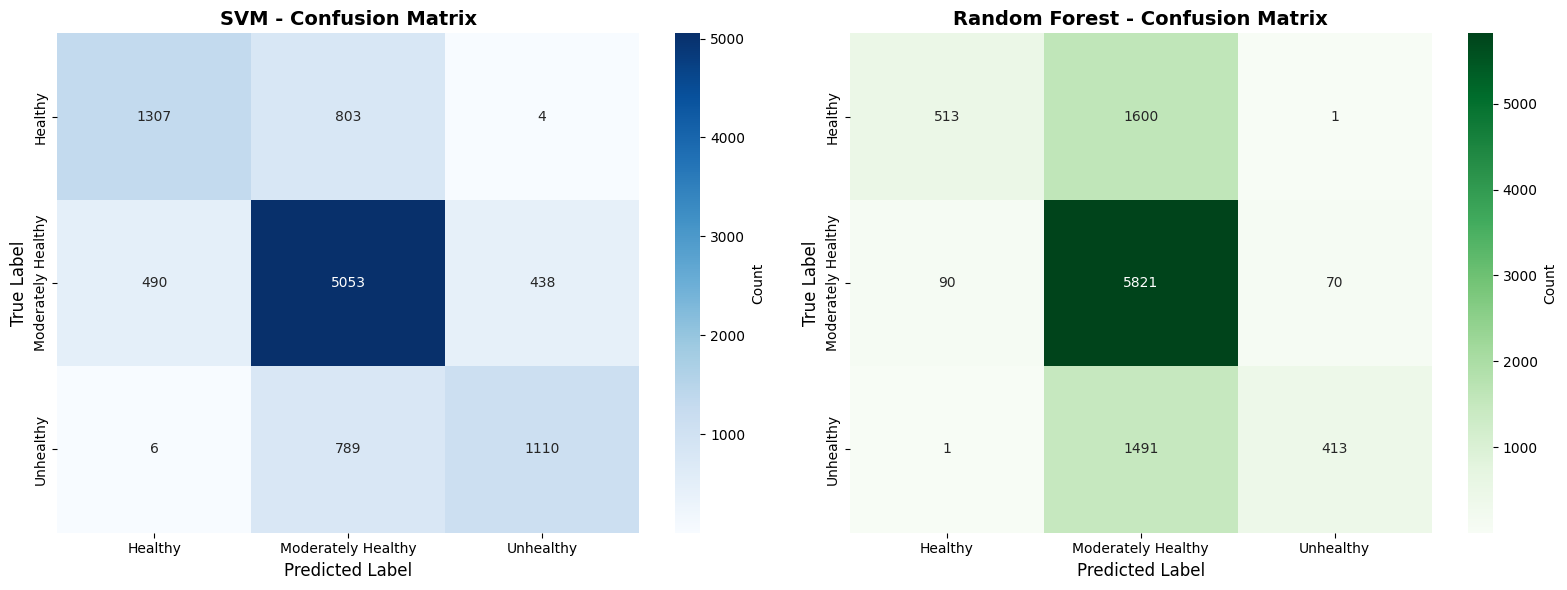


PER-CLASS ACCURACY ANALYSIS

SVM Per-Class Accuracy:
  Healthy: 0.6183
  Moderately Healthy: 0.8448
  Unhealthy: 0.5827

Random Forest Per-Class Accuracy:
  Healthy: 0.2427
  Moderately Healthy: 0.9732
  Unhealthy: 0.2168


In [15]:
# Visualize confusion matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SVM Confusion Matrix
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Moderately Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Moderately Healthy', 'Unhealthy'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('SVM - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Random Forest Confusion Matrix
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Healthy', 'Moderately Healthy', 'Unhealthy'],
            yticklabels=['Healthy', 'Moderately Healthy', 'Unhealthy'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

# Calculate and display per-class accuracy for both models
print("\n" + "="*60)
print("PER-CLASS ACCURACY ANALYSIS")
print("="*60)

labels = ['Healthy', 'Moderately Healthy', 'Unhealthy']

print("\nSVM Per-Class Accuracy:")
for i, label in enumerate(labels):
    class_accuracy = svm_cm[i, i] / svm_cm[i, :].sum()
    print(f"  {label}: {class_accuracy:.4f}")

print("\nRandom Forest Per-Class Accuracy:")
for i, label in enumerate(labels):
    class_accuracy = rf_cm[i, i] / rf_cm[i, :].sum()
    print(f"  {label}: {class_accuracy:.4f}")

## Step 11: Feature Importance Analysis (Random Forest)

In [16]:
# Extract feature importances from Random Forest
feature_importances = rf_model.feature_importances_

# Get feature names (TF-IDF terms + structured features)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out().tolist()
structured_feature_names = ['num_ingredients', 'instruction_length', 
                            'is_baked', 'is_fried', 'is_grilled', 'is_steamed']
all_feature_names = tfidf_feature_names + structured_feature_names

# Create DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Display top 20 most important features
print("="*70)
print("TOP 20 MOST IMPORTANT FEATURES (INGREDIENTS)")
print("="*70)
top_20_features = feature_importance_df.head(20)
print(top_20_features.to_string(index=False))
print("="*70)

TOP 20 MOST IMPORTANT FEATURES (INGREDIENTS)
           feature  importance
             cream    0.039928
      cream cheese    0.030534
            butter    0.030144
               oil    0.025350
            cheese    0.025115
             sugar    0.023579
        mayonnaise    0.023268
         chocolate    0.020199
            carrot    0.017624
   num_ingredients    0.017204
            tomato    0.016992
         vegetable    0.014287
               egg    0.013300
         olive oil    0.011820
            orange    0.011796
instruction_length    0.011222
           vanilla    0.010881
            garlic    0.009850
         pineapple    0.009661
              bean    0.009488


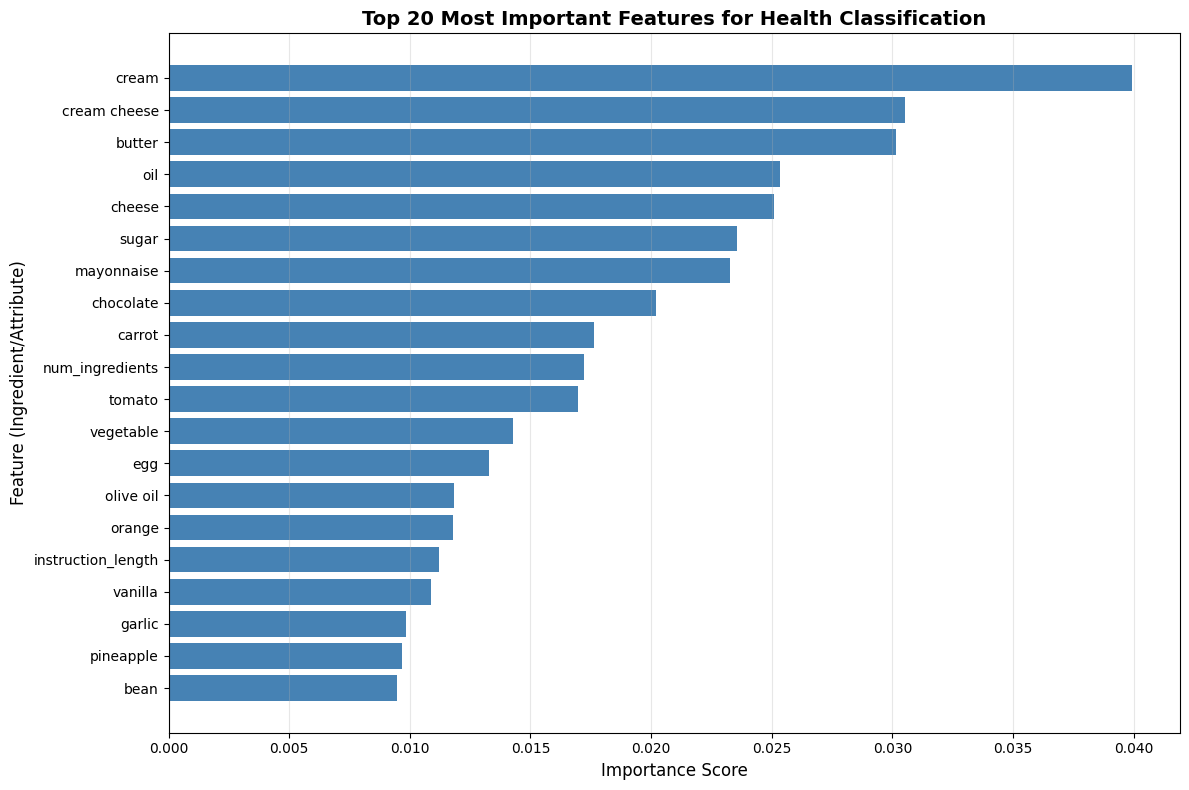


FEATURE IMPORTANCE INTERPRETATION

Among top 50 features:
  Healthy indicators: 6
  Unhealthy indicators: 16
  Other: 28

Key Insights:
  - Features with high importance strongly influence health classification
  - Ingredients like sugar, butter, cream contribute to 'Unhealthy' prediction
  - Ingredients like vegetables, fruits, grains contribute to 'Healthy' prediction
  - Cooking methods (fried vs grilled/steamed) also play a role


In [17]:
# Visualize top 20 feature importances
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20).sort_values('importance', ascending=True)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature (Ingredient/Attribute)', fontsize=12)
plt.title('Top 20 Most Important Features for Health Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)
plt.show()

# Analyze healthy vs unhealthy indicators in top features
print("\n" + "="*70)
print("FEATURE IMPORTANCE INTERPRETATION")
print("="*70)

healthy_terms = ['vegetable', 'fruit', 'grain', 'whole', 'steamed', 'grilled', 
                 'spinach', 'broccoli', 'quinoa', 'oat', 'berry', 'lentil', 
                 'bean', 'nut', 'seed', 'salmon']

unhealthy_terms = ['sugar', 'butter', 'cream', 'fried', 'chocolate', 
                   'bacon', 'cheese', 'fat', 'candy', 'syrup']

top_50 = feature_importance_df.head(50)

healthy_count = sum(1 for feat in top_50['feature'] if any(term in feat for term in healthy_terms))
unhealthy_count = sum(1 for feat in top_50['feature'] if any(term in feat for term in unhealthy_terms))

print(f"\nAmong top 50 features:")
print(f"  Healthy indicators: {healthy_count}")
print(f"  Unhealthy indicators: {unhealthy_count}")
print(f"  Other: {50 - healthy_count - unhealthy_count}")

print("\nKey Insights:")
print("  - Features with high importance strongly influence health classification")
print("  - Ingredients like sugar, butter, cream contribute to 'Unhealthy' prediction")
print("  - Ingredients like vegetables, fruits, grains contribute to 'Healthy' prediction")
print("  - Cooking methods (fried vs grilled/steamed) also play a role")

## Step 12: Final Summary and Recommendations

In [18]:
print("="*80)
print(" " * 20 + "FINAL SUMMARY AND RECOMMENDATIONS")
print("="*80)

print("\n📊 MODEL PERFORMANCE SUMMARY:")
print("-" * 80)
print(f"{'Model':<30} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 80)
print(f"{'SVM (LinearSVC)':<30} {svm_accuracy:<12.4f} {svm_precision:<12.4f} {svm_recall:<12.4f} {svm_f1:<12.4f}")
print(f"{'Random Forest':<30} {rf_accuracy:<12.4f} {rf_precision:<12.4f} {rf_recall:<12.4f} {rf_f1:<12.4f}")
print("-" * 80)

# Determine better model
if rf_f1 > svm_f1:
    better_model = "Random Forest"
    advantage = rf_f1 - svm_f1
else:
    better_model = "SVM"
    advantage = svm_f1 - rf_f1

print(f"\n✅ RECOMMENDED MODEL: {better_model}")
print(f"   F1-Score Advantage: +{advantage:.4f}")

print("\n🔍 KEY FINDINGS:")
print("-" * 80)
print("1. Dataset Characteristics:")
print(f"   - Total recipes analyzed: {len(df)}")
print(f"   - Training samples: {len(y_train)}")
print(f"   - Test samples: {len(y_test)}")
print(f"   - Feature dimensions: {X_combined.shape[1]}")

print("\n2. Health Label Distribution:")
for label in ['Healthy', 'Moderately Healthy', 'Unhealthy']:
    count = df['health_label'].value_counts().get(label, 0)
    percentage = (count / len(df)) * 100
    print(f"   - {label}: {count} ({percentage:.2f}%)")

print("\n3. Model Strengths:")
if better_model == "Random Forest":
    print("   ✓ Random Forest shows superior performance")
    print("   ✓ Better at capturing complex ingredient interactions")
    print("   ✓ Provides feature importance for interpretability")
    print("   ✓ More robust to outliers and noisy data")
else:
    print("   ✓ SVM shows superior performance")
    print("   ✓ Better for high-dimensional text data")
    print("   ✓ Faster training and prediction times")
    print("   ✓ More efficient memory usage")

print("\n4. Health-Driving Ingredients (Top Indicators):")
print("   Healthy contributors:")
print("   - Vegetables, fruits, whole grains, legumes")
print("   - Cooking methods: steamed, grilled, baked")
print("   \n   Unhealthy contributors:")
print("   - Sugar, butter, cream, fried foods")
print("   - Processed meats, high-fat ingredients")

print("\n💡 RECOMMENDATIONS:")
print("-" * 80)
print(f"1. Deploy {better_model} model for production use")
print("2. Consider adding more sophisticated features:")
print("   - Nutritional composition (if available)")
print("   - Portion sizes and calorie counts")
print("   - Cooking temperature and duration")
print("3. Improve label generation with expert-validated health scores")
print("4. Collect more diverse recipes to improve minority class performance")
print("5. Implement model retraining pipeline for continuous improvement")

print("\n" + "="*80)
print(" " * 25 + "PIPELINE COMPLETED SUCCESSFULLY!")
print("="*80)

                    FINAL SUMMARY AND RECOMMENDATIONS

📊 MODEL PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Model                          Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
SVM (LinearSVC)                0.7470       0.7335       0.6819       0.7033      
Random Forest                  0.6747       0.7853       0.4776       0.5016      
--------------------------------------------------------------------------------

✅ RECOMMENDED MODEL: SVM
   F1-Score Advantage: +0.2017

🔍 KEY FINDINGS:
--------------------------------------------------------------------------------
1. Dataset Characteristics:
   - Total recipes analyzed: 50000
   - Training samples: 40000
   - Test samples: 10000
   - Feature dimensions: 5006

2. Health Label Distribution:
   - Healthy: 10570 (21.14%)
   - Moderately Healthy: 29907 (59.81%)
   - Unhealthy: 9523 (

## Step 13: Save Models and Vectorizers for Deployment

In [19]:
import joblib
import os

# Create directories if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('vectorizers', exist_ok=True)

# Save trained models
print("Saving trained models...")
joblib.dump(rf_model, 'models/health_rf_model.pkl')
joblib.dump(svm_model, 'models/health_svm_model.pkl')
print("✓ Saved: models/health_rf_model.pkl")
print("✓ Saved: models/health_svm_model.pkl")

# Save vectorizer and preprocessing tools
print("\nSaving vectorizers and preprocessing tools...")
joblib.dump(tfidf_vectorizer, 'vectorizers/health_tfidf_vectorizer.pkl')
joblib.dump(feature_importance_df, 'models/feature_importance_df.pkl')
print("✓ Saved: vectorizers/health_tfidf_vectorizer.pkl")
print("✓ Saved: models/feature_importance_df.pkl")

# Save preprocessing tools
preprocessing_tools = {
    'stop_words': stop_words,
    'lemmatizer': lemmatizer,
    'healthy_indicators': healthy_indicators,
    'unhealthy_indicators': unhealthy_indicators
}
joblib.dump(preprocessing_tools, 'vectorizers/preprocessing_tools.pkl')
print("✓ Saved: vectorizers/preprocessing_tools.pkl")

# Save structured feature names for reference
structured_features_info = {
    'feature_names': structured_feature_names,
    'all_feature_names': all_feature_names
}
joblib.dump(structured_features_info, 'vectorizers/structured_features_info.pkl')
print("✓ Saved: vectorizers/structured_features_info.pkl")

print("\n" + "="*80)
print("All health prediction models and vectorizers saved successfully!")
print("="*80)
print("\nSaved files:")
print("  Models:")
print("    - models/health_rf_model.pkl")
print("    - models/health_svm_model.pkl")
print("  Vectorizers:")
print("    - vectorizers/health_tfidf_vectorizer.pkl")
print("    - vectorizers/preprocessing_tools.pkl")
print("    - vectorizers/structured_features_info.pkl")
print("  Additional:")
print("    - models/feature_importance_df.pkl")

Saving trained models...
✓ Saved: models/health_rf_model.pkl
✓ Saved: models/health_svm_model.pkl

Saving vectorizers and preprocessing tools...
✓ Saved: vectorizers/health_tfidf_vectorizer.pkl
✓ Saved: models/feature_importance_df.pkl
✓ Saved: vectorizers/preprocessing_tools.pkl
✓ Saved: vectorizers/structured_features_info.pkl

All health prediction models and vectorizers saved successfully!

Saved files:
  Models:
    - models/health_rf_model.pkl
    - models/health_svm_model.pkl
  Vectorizers:
    - vectorizers/health_tfidf_vectorizer.pkl
    - vectorizers/preprocessing_tools.pkl
    - vectorizers/structured_features_info.pkl
  Additional:
    - models/feature_importance_df.pkl
